It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

The fraud usually occurs when someone accesses your credit or debit card numbers from unsecured websites or via an identity theft scheme to fraudulently obtain money or property. Due to its recurrence and the harm it may cause to both individuals and financial institutions, it is crucial to take preventive measures as well as identifying when a transaction is fraudulent.

Import Libraries

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv1D, MaxPool1D
from tensorflow.keras.optimizers import Adam

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler    # in order to scale data
from sklearn.metrics import classification_report,accuracy_score


import warnings as wr
wr.filterwarnings("ignore")

Upload Data

In [ ]:
data = pd.read_csv("https://cainvas-static.s3.amazonaws.com/media/user_data/cainvas-admin/creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


492 frauds out of 284,807 transactions
features V1 - V28 are a result of the PCA transformation and are simply numerical representations
"Amount" is the value in dollars of the transaction
"Time" variable is the amount of time that passed from the time when the first transaction took place.
Fraud = 1 , Not Fraud = 0

In [ ]:
 # Check data shape
 data.shape

(284807, 31)

In [ ]:
# Check for null values
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
# Check for variable types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
data.Class.values

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
data.Class.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Data Visualization

<Axes: xlabel='Class'>

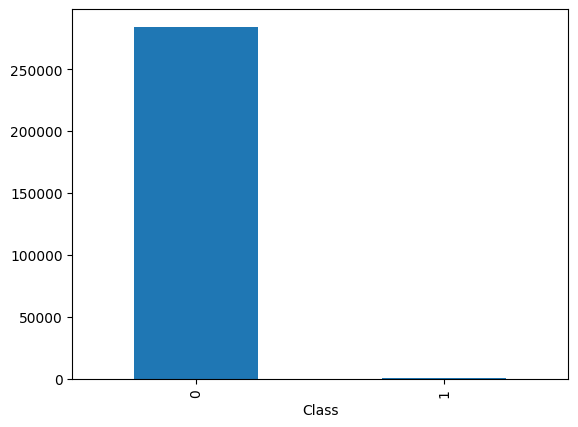

In [ ]:
data['Class'].value_counts().plot(kind='bar')

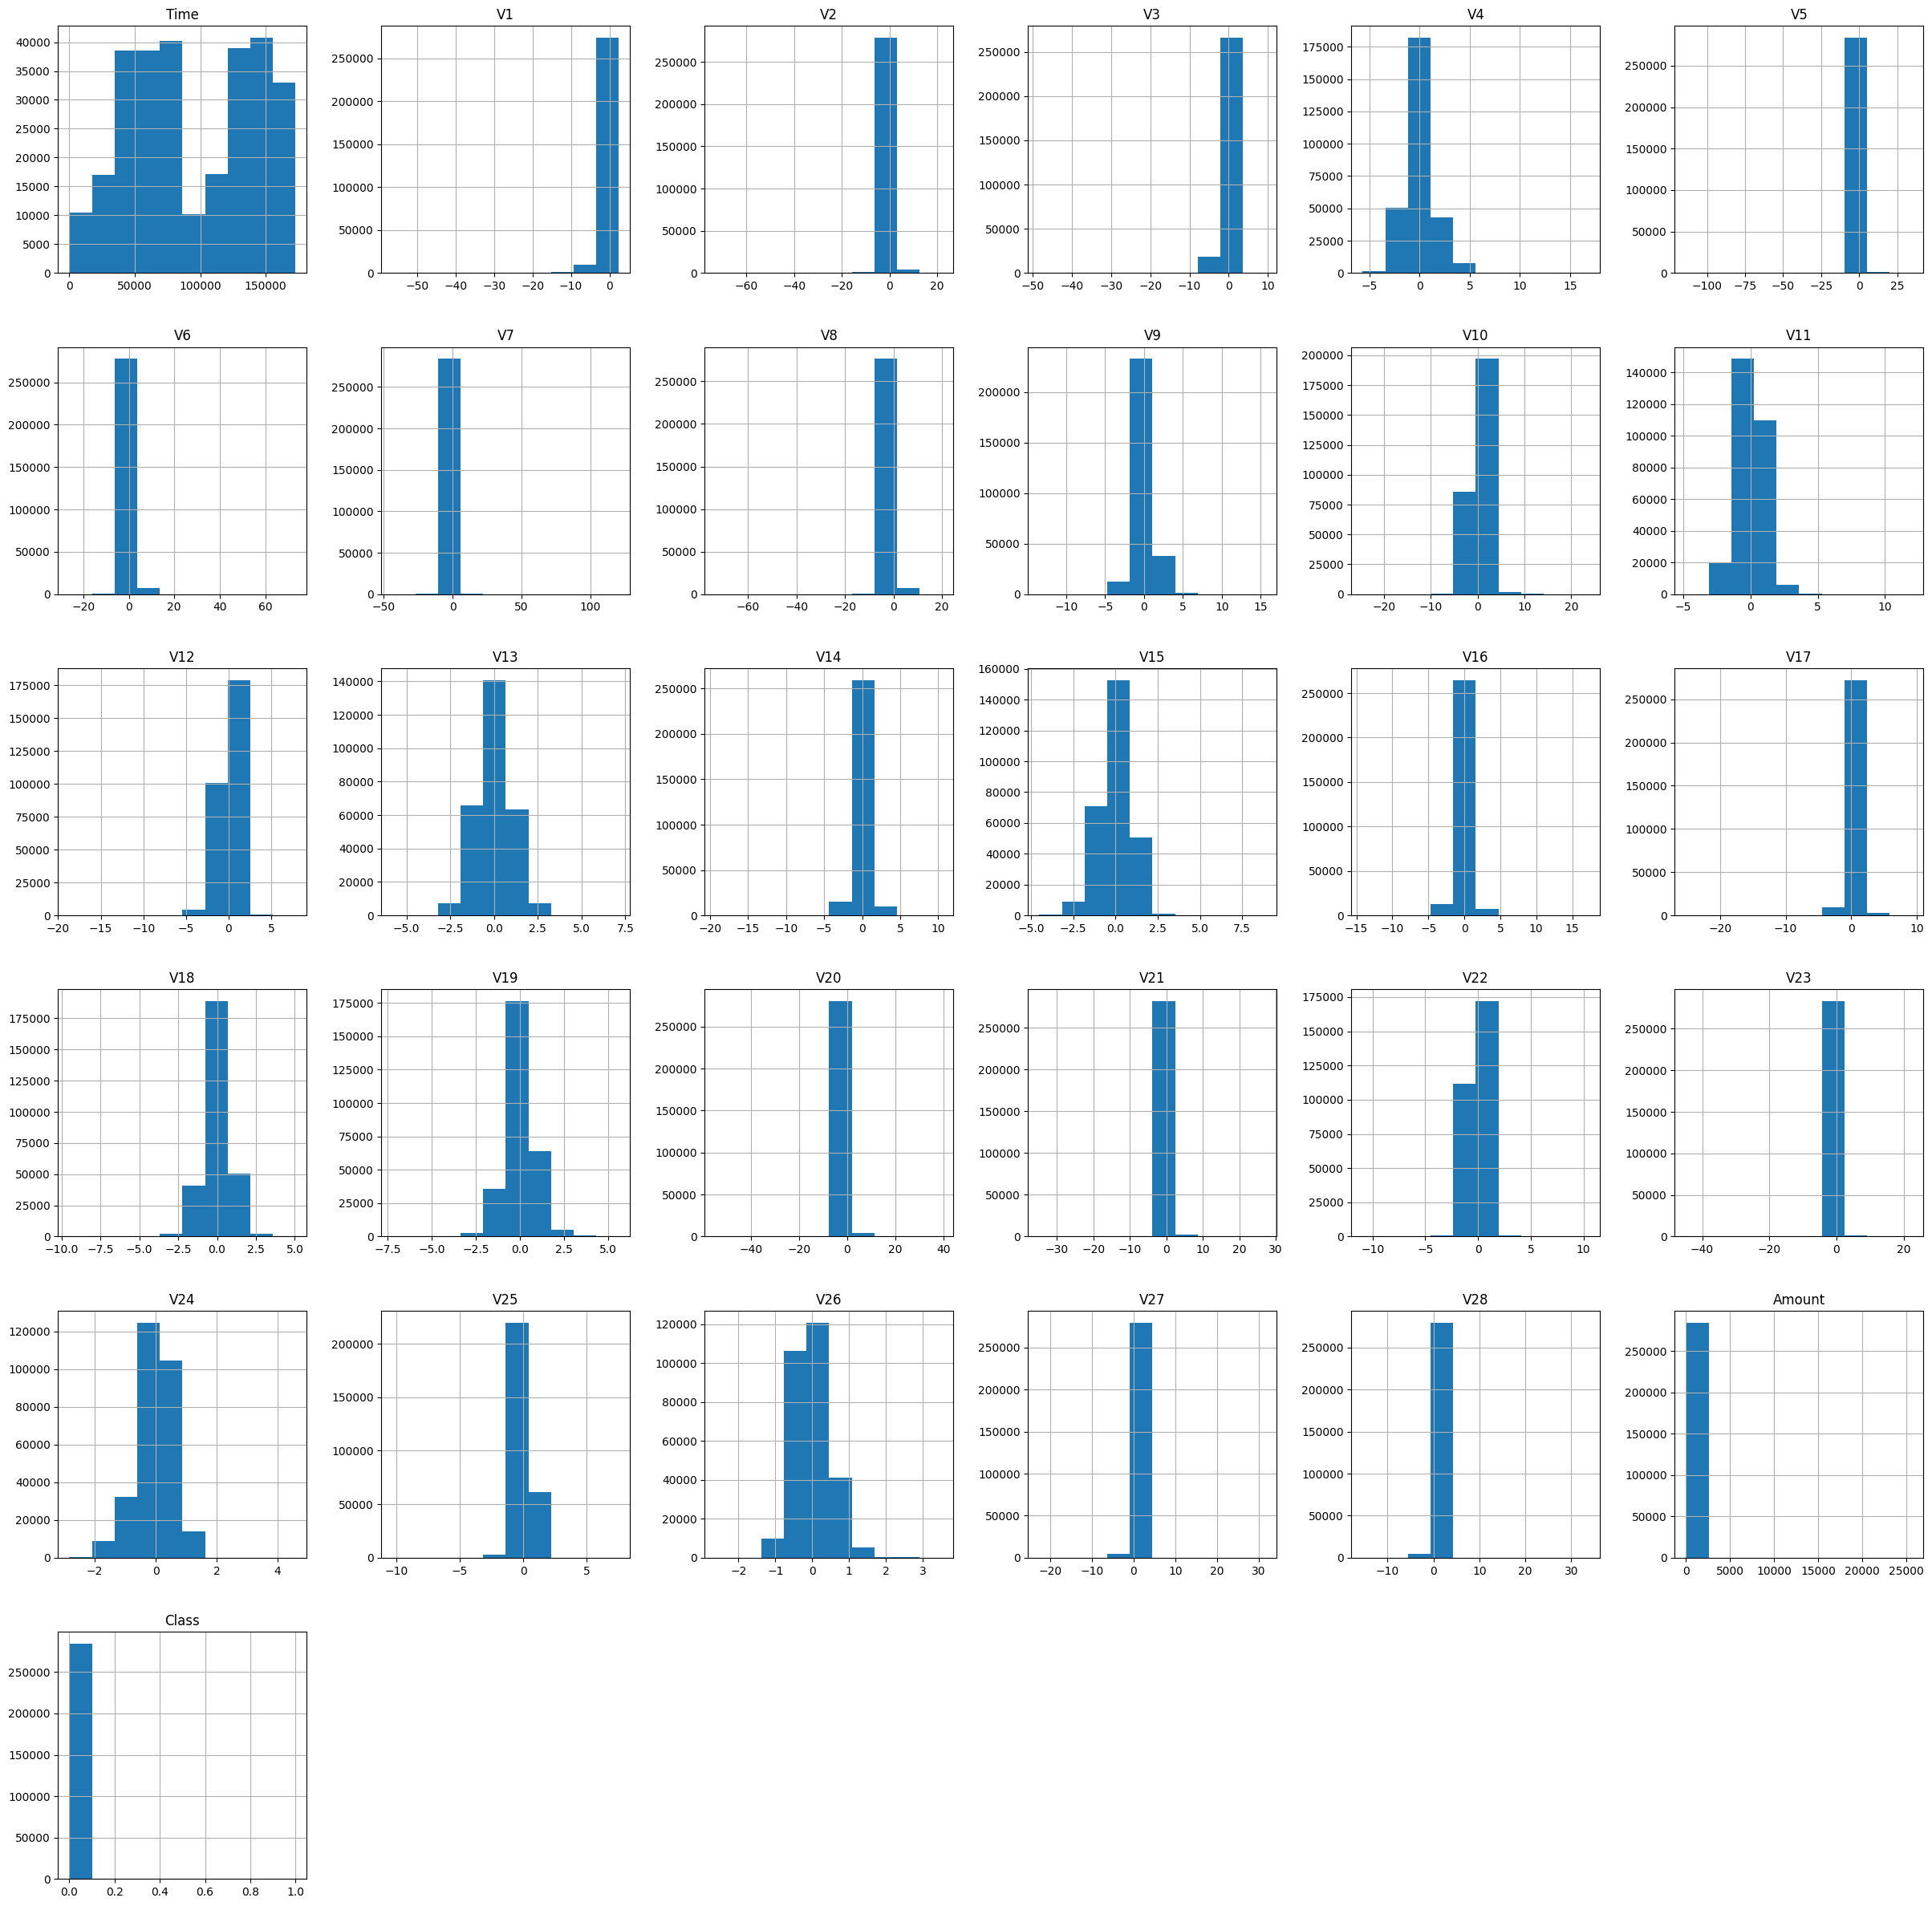

In [ ]:
data.hist(figsize=(30,30))
plt.show()

Data Pre-processing

In [ ]:
fraud = data[data.Class == 1]
fraud      # Each row with class = 1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [ ]:
non_fraud = data[data.Class == 0]
non_fraud  # Each row with class = 0

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
print("Shape of fraud data:", fraud.shape)
print("Shape of non-fraus data:", non_fraud.shape)

Shape of fraud data: (492, 31)
Shape of non-fraus data: (284315, 31)


Balancing the Dataset

In [ ]:
nan_fraud_balanced = non_fraud.sample(4000)

In [ ]:
nan_fraud_balanced

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
155604,105881.0,-0.309380,0.599395,1.739216,-0.083561,-0.080196,-0.132699,0.243477,-0.079544,1.443064,...,0.179994,0.951550,-0.193172,-0.046382,-0.393131,0.634270,0.115596,0.158530,29.90,0
231760,146913.0,-1.910806,2.327090,-1.407073,-0.579490,-0.167703,-1.428491,0.342530,0.509669,0.560288,...,0.285033,1.291776,0.138384,0.018475,-0.423930,-0.195948,0.717709,0.459338,0.89,0
107652,70544.0,-7.513790,-2.384135,-2.879596,3.334156,0.777561,4.767700,-3.308692,-2.896002,-2.243731,...,-2.727370,0.938038,0.380931,1.170852,0.329514,0.381915,0.467450,-2.052965,10.85,0
250472,154927.0,-1.188830,0.876961,0.742428,1.047434,0.695698,0.494714,0.312902,0.473141,-0.015736,...,-0.280124,-0.302960,-0.191352,0.710687,0.025744,-0.714357,0.291582,-0.059220,11.00,0
234723,148084.0,-0.542899,-0.025640,-0.018010,1.013802,0.270026,-0.492344,-0.296438,0.464636,-0.833996,...,-0.106273,-0.767473,0.550115,-0.415999,-1.974349,0.284575,0.140210,0.070082,52.76,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45977,42589.0,-2.130843,-2.021072,1.452040,-1.336653,-1.385995,-0.426480,1.590442,-0.063670,1.101941,...,0.614325,0.722072,1.098198,0.349272,0.599379,-0.710808,-0.074029,0.167539,560.00,0
172581,121158.0,-0.502713,-0.077330,1.396637,-1.104490,0.656909,0.435338,0.213112,0.126350,0.589767,...,0.248528,0.827169,-0.231951,0.218684,-0.170481,0.063285,-0.043406,-0.070237,33.82,0
158309,111123.0,2.083135,-0.105395,-1.577463,0.145326,0.474510,-0.244039,-0.159473,-0.091857,2.077939,...,0.105914,0.584042,-0.041860,0.006942,0.322620,-0.466737,-0.038929,-0.073342,1.00,0
260049,159381.0,1.288398,-2.056613,-1.959352,-0.533580,-0.806837,-1.239940,0.593433,-0.627795,-0.910801,...,0.358741,-0.060613,-0.228691,-0.030728,-0.214247,-0.362629,-0.129907,0.023683,500.00,0


In [ ]:
balanced_data = pd.concat([fraud, nan_fraud_balanced], ignore_index=True)

In [ ]:
balanced_data

# 492 of them Class = 1 (fraud), 492 of them Class = 0 (nan_fraud)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
1,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
2,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
3,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
4,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4487,42589.0,-2.130843,-2.021072,1.452040,-1.336653,-1.385995,-0.426480,1.590442,-0.063670,1.101941,...,0.614325,0.722072,1.098198,0.349272,0.599379,-0.710808,-0.074029,0.167539,560.00,0
4488,121158.0,-0.502713,-0.077330,1.396637,-1.104490,0.656909,0.435338,0.213112,0.126350,0.589767,...,0.248528,0.827169,-0.231951,0.218684,-0.170481,0.063285,-0.043406,-0.070237,33.82,0
4489,111123.0,2.083135,-0.105395,-1.577463,0.145326,0.474510,-0.244039,-0.159473,-0.091857,2.077939,...,0.105914,0.584042,-0.041860,0.006942,0.322620,-0.466737,-0.038929,-0.073342,1.00,0
4490,159381.0,1.288398,-2.056613,-1.959352,-0.533580,-0.806837,-1.239940,0.593433,-0.627795,-0.910801,...,0.358741,-0.060613,-0.228691,-0.030728,-0.214247,-0.362629,-0.129907,0.023683,500.00,0


In [ ]:
balanced_data.Class.value_counts()

Class
0    4000
1     492
Name: count, dtype: int64

In [ ]:
x = balanced_data.drop("Class", axis = 1)
x # Dataset without Class column

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00
1,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00
2,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93
3,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,-0.171608,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00
4,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,0.009061,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4487,42589.0,-2.130843,-2.021072,1.452040,-1.336653,-1.385995,-0.426480,1.590442,-0.063670,1.101941,...,1.297014,0.614325,0.722072,1.098198,0.349272,0.599379,-0.710808,-0.074029,0.167539,560.00
4488,121158.0,-0.502713,-0.077330,1.396637,-1.104490,0.656909,0.435338,0.213112,0.126350,0.589767,...,0.117369,0.248528,0.827169,-0.231951,0.218684,-0.170481,0.063285,-0.043406,-0.070237,33.82
4489,111123.0,2.083135,-0.105395,-1.577463,0.145326,0.474510,-0.244039,-0.159473,-0.091857,2.077939,...,-0.348758,0.105914,0.584042,-0.041860,0.006942,0.322620,-0.466737,-0.038929,-0.073342,1.00
4490,159381.0,1.288398,-2.056613,-1.959352,-0.533580,-0.806837,-1.239940,0.593433,-0.627795,-0.910801,...,1.013499,0.358741,-0.060613,-0.228691,-0.030728,-0.214247,-0.362629,-0.129907,0.023683,500.00


In [ ]:
y = balanced_data.Class
y

0       1
1       1
2       1
3       1
4       1
       ..
4487    0
4488    0
4489    0
4490    0
4491    0
Name: Class, Length: 4492, dtype: int64

<Axes: xlabel='Class'>

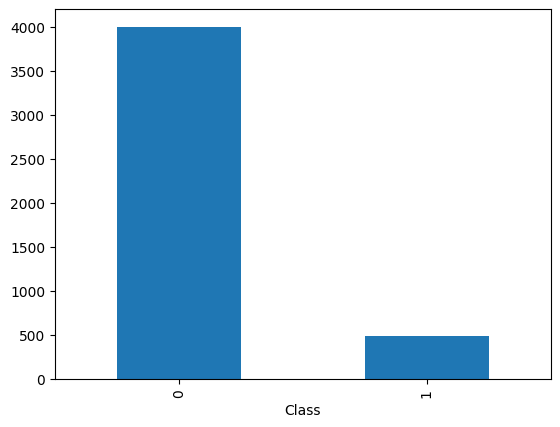

In [ ]:
y.value_counts().plot(kind='bar')

Training and Testing Part

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 42)


In [ ]:
xtrain.shape

(3593, 30)

In [ ]:
xtest.shape

(899, 30)

Standardation

In [ ]:
scaler = StandardScaler()

In [ ]:
scaled_xtrain = scaler.fit_transform(xtrain)
scaled_xtest = scaler.fit_transform(xtest)

In [ ]:
scaled_xtrain

array([[-1.20997056e+00, -1.39017805e+00,  2.27455116e+00, ...,
         3.41736750e-01,  1.24954939e+00,  7.41251697e-02],
       [-1.79782983e+00, -3.58890600e-01,  1.24751679e+00, ...,
         4.33946039e-01,  3.95933808e-01, -3.42148898e-01],
       [ 1.52453238e+00,  7.36872479e-01, -4.42808168e-02, ...,
        -8.89430460e-04, -1.78569526e-01, -2.89541181e-01],
       ...,
       [-8.35430765e-01,  5.24358472e-01, -1.58205437e-01, ...,
         1.11614298e-01,  6.42844527e-02, -2.97061941e-01],
       [-6.46621145e-01,  3.14594332e-02,  1.35792914e-01, ...,
         1.97452179e-01,  4.16355391e-01, -3.42562540e-01],
       [-4.45807984e-01,  5.19885209e-01, -1.64189796e-01, ...,
         2.37492589e-02, -6.98792094e-02, -2.14220770e-01]])

In [ ]:
type(scaled_xtrain)

numpy.ndarray

In [ ]:
print(scaled_xtrain.shape)
print(scaled_xtest.shape)

(3593, 30)
(899, 30)


In [ ]:
print(ytrain.shape)
print(ytest.shape)

(3593,)
(899,)


In [ ]:
190820+93987 #Total dataset rows

284807

3D Format

In [ ]:
scaled_xtrain3d = scaled_xtrain.reshape(scaled_xtrain.shape[0],scaled_xtrain.shape[1],1)
scaled_xtest3d = scaled_xtest.reshape(scaled_xtest.shape[0],scaled_xtest.shape[1],1)

scaled_xtrain3d.shape, scaled_xtest3d.shape

((3593, 30, 1), (899, 30, 1))

Network Building

In [ ]:
# First Layer:

cnn = Sequential()
cnn.add(Conv1D(32, 2, activation = "relu", input_shape = (30,1)))
cnn.add(Dropout(0.1))

In [ ]:
# Second Layer:

cnn.add(BatchNormalization()) # Batch normalization is a technique for training very deep neural networks
                               # that standardizes the inputs to a layer for each mini-batch. This
                               # has the effect of stabilizing the learning process and dramatically
                               # reducing the number of training epochs required to train deep networks

cnn.add(Conv1D(64, 2, activation = "relu"))
cnn.add(Dropout(0.2))          # prevents over-fitting (randomly remove some neurons)

In [ ]:
# Flattening Layer:

cnn.add(Flatten())
cnn.add(Dropout(0.4))
cnn.add(Dense(64, activation = "relu"))
cnn.add(Dropout(0.5))

In [ ]:
# Last Layer:

cnn.add(Dense(1, activation = "sigmoid"))

In [ ]:
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 29, 32)            96        
                                                                 
 dropout (Dropout)           (None, 29, 32)            0         
                                                                 
 batch_normalization (Batch  (None, 29, 32)            128       
 Normalization)                                                  
                                                                 
 conv1d_1 (Conv1D)           (None, 28, 64)            4160      
                                                                 
 dropout_1 (Dropout)         (None, 28, 64)            0         
                                                                 
 flatten (Flatten)           (None, 1792)              0         
                                                        

In [ ]:
cnn.compile(optimizer = Adam(lr=0.0001), loss = "binary_crossentropy", metrics = ["accuracy"])

Training

In [ ]:
history = cnn.fit(scaled_xtrain3d, ytrain, epochs = 20, validation_data=(scaled_xtest3d, ytest), verbose=1)


Epoch 1/20
113/113 [==============================] - 8s 14ms/step - loss: 0.1445 - accuracy: 0.9652 - val_loss: 0.2976 - val_accuracy: 0.9855
Epoch 2/20
113/113 [==============================] - 1s 7ms/step - loss: 0.0858 - accuracy: 0.9783 - val_loss: 0.1710 - val_accuracy: 0.9889
Epoch 3/20
113/113 [==============================] - 1s 6ms/step - loss: 0.0797 - accuracy: 0.9791 - val_loss: 0.1009 - val_accuracy: 0.9900
Epoch 4/20
113/113 [==============================] - 1s 6ms/step - loss: 0.0760 - accuracy: 0.9769 - val_loss: 0.0572 - val_accuracy: 0.9889
Epoch 5/20
113/113 [==============================] - 1s 6ms/step - loss: 0.0725 - accuracy: 0.9780 - val_loss: 0.0467 - val_accuracy: 0.9900
Epoch 6/20
113/113 [==============================] - 1s 6ms/step - loss: 0.0680 - accuracy: 0.9808 - val_loss: 0.0533 - val_accuracy: 0.9878
Epoch 7/20
113/113 [==============================] - 1s 6ms/step - loss: 0.0702 - accuracy: 0.9825 - val_loss: 0.0514 - val_accuracy: 0.9889
Epoch

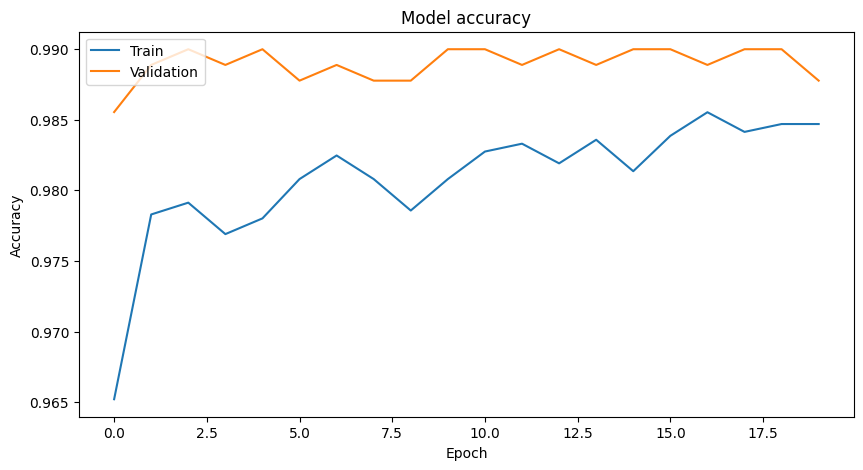

In [ ]:
fig, ax1 = plt.subplots(figsize= (10, 5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc = "upper left")
plt.show()


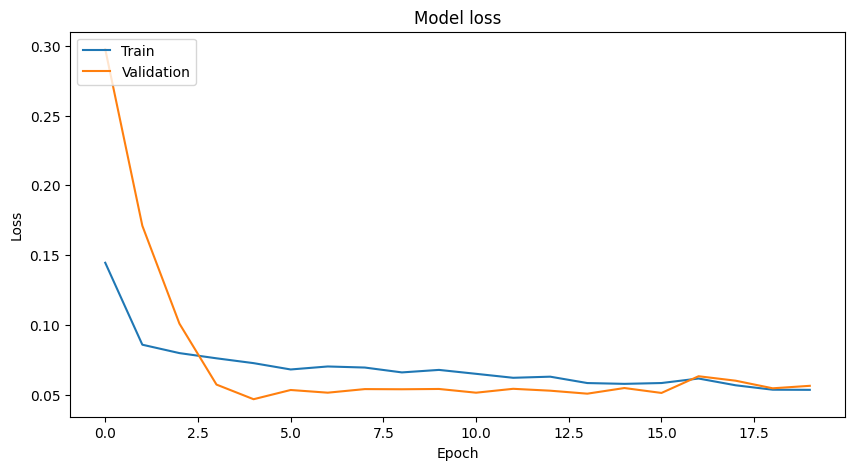

In [ ]:
fig, ax1 = plt.subplots(figsize= (10, 5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc = "upper left")
plt.show()

Evaluation

29/29 [==============================] - 0s 3ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       794
           1       0.97      0.92      0.95       105

    accuracy                           0.99       899
   macro avg       0.98      0.96      0.97       899
weighted avg       0.99      0.99      0.99       899

Accuracy Score: 0.9877641824249166


[Text(0, 0.5, 'Not Fraud'), Text(0, 1.5, 'Fraud')]

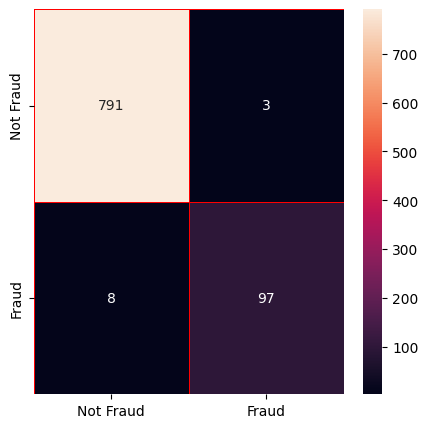

In [ ]:
from sklearn.metrics import confusion_matrix

cnn_predictions = cnn.predict(scaled_xtest3d)
cnn_predictions = (cnn_predictions > 0.5)
cnn_predictions = cnn_predictions.astype(int)
print("Classification Report:")
print(classification_report(ytest, cnn_predictions))
print("Accuracy Score:",accuracy_score(ytest, cnn_predictions))

# Confusion Matrix
cm = confusion_matrix(ytest, cnn_predictions)
labels = ['Not Fraud', 'Fraud']

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.6, linecolor="r", fmt=".0f", ax=ax)

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)


In [ ]:
accuracy_score(ytest, cnn_predictions)

0.9877641824249166

In [ ]:
from sklearn.metrics import precision_recall_fscore_support as score

In [ ]:
precision, recall, fscore, support = score(ytest, cnn_predictions)
print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))

precision: [0.98998748 0.97      ]
recall: [0.99622166 0.92380952]
fscore: [0.99309479 0.94634146]
support: [794 105]


In [ ]:
cnn.save('fraud_detection_model.h5')